In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# %matplotlib inline

In [2]:
df_index=pd.read_csv("economic_index.csv")

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
#drop unneccessary columns
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
##check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

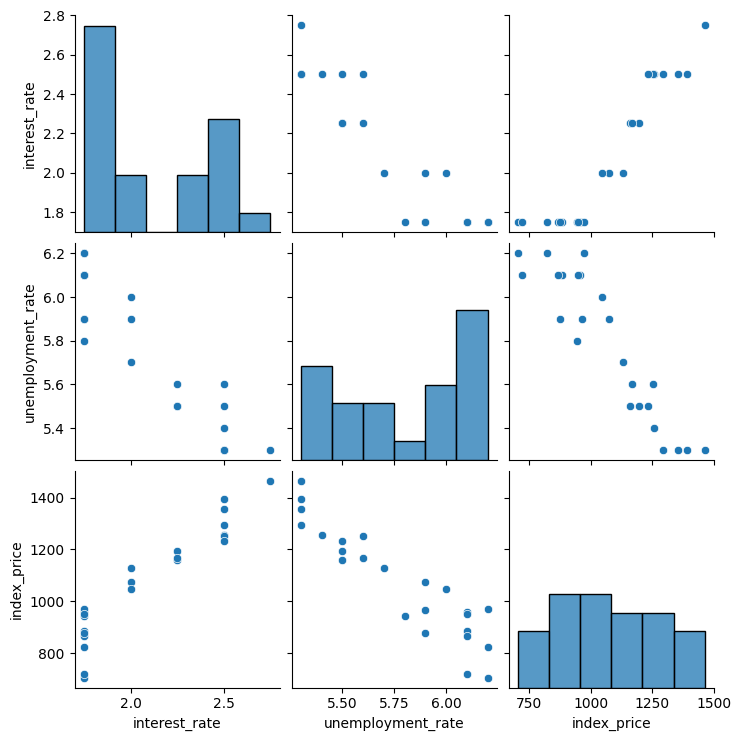

In [ ]:
## Lets do some viualization
sns.pairplot(df_index)
# with respect to targe variable (index price): 
#     Interest rate shows +ve correlation 
#     & unemployment shows -ve correlation

In [ ]:
df_index.corr() ##the above conclusion can be seen here

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


## EDA

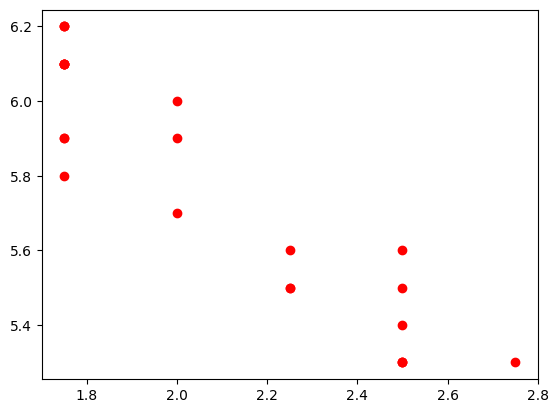

In [8]:
## Visualiza the datapoints more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')

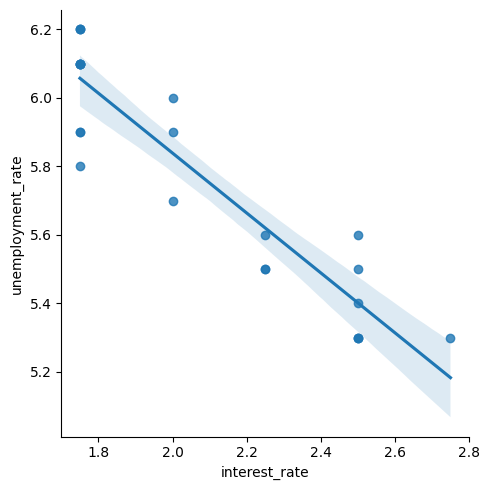

In [15]:
##Regression Plot
sns.lmplot(data=df_index, x= 'interest_rate', y ='unemployment_rate')

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

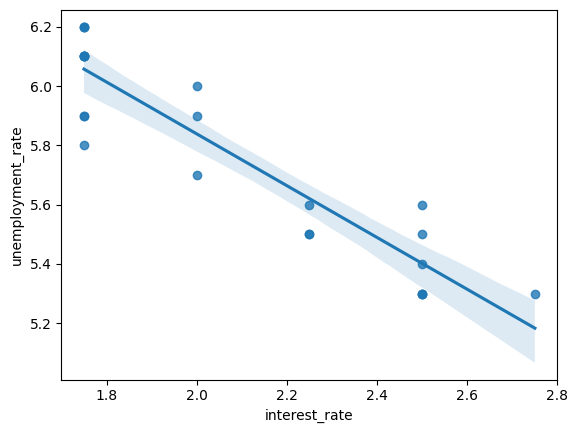

In [16]:
sns.regplot(data=df_index, x= 'interest_rate', y ='unemployment_rate')

In [19]:
##independent and dependent features
X=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

<h5> *** Testing Multicolinearity *** </h5>

In [ ]:
df_index.corr() ##Xs => have high correlation

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [18]:
##VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data

,feature
0,interest_rate
1,unemployment_rate


In [ ]:
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

print(vif_data) ##Can see for both factor VIF is high as 21 which is alarming

             feature        VIF
0      interest_rate  21.699835
1  unemployment_rate  21.699835


In [23]:
##Since features are less dropping doesn't make sense, can combine the two or PCA
from sklearn.decomposition import PCA

In [24]:
pca = PCA(n_components= 1)

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler

In [29]:
std_scaler = StandardScaler()
X_train_scal = std_scaler.fit_transform(X_train)

In [31]:
X_train_pca = pca.fit_transform(X_train_scal)

<h3> Linear Regression </h3>

In [32]:
from sklearn.linear_model import LinearRegression

In [51]:
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train_pca, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [59]:
from sklearn.model_selection import cross_val_score
from sklearn import metrics

In [ ]:
scores_cv = -cross_val_score(estimator=lr, X= X_train_pca, y= y_train,\
                              cv = 5, scoring= "neg_root_mean_squared_error")

In [44]:
print("Mean RMSE:", scores_cv.mean())
print("Std Dev RMSE:", scores_cv.std()) ##SD & Mean difference quite high
print("Std Dev RMSE:", scores_cv) ## also quite difference in spread

Mean RMSE: 65.51121911909208
Std Dev RMSE: 25.938218643537162
Std Dev RMSE: [40.59790082 78.15651558 89.28678262 90.99756515 28.51733143]


In [93]:
## Checking whether PCA Made it worse
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train_scal, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [49]:
scr1 = -cross_val_score(estimator=lr, X= X_train_scal, y= y_train, cv = 5, scoring= "neg_root_mean_squared_error") ##is not drastic change

In [ ]:
print("Mean RMSE:", scr1.mean())
print("Std Dev RMSE:", scr1.std()) ##SD & Mean difference quite high
print("Std Dev RMSE:", scr1)
##Without PCA It didn't Improve. PCA Is good to use but still variability

Mean RMSE: 69.32064869228478
Std Dev RMSE: 29.28094050786773
Std Dev RMSE: [40.08084433 97.87723582 89.22785081 91.60963636 27.80767614]


<h5> Performance Evaluation </h5>

In [76]:
##Without Pca
lr.fit(X_train_scal, y_train)

y_pred1 = lr.predict(std_scaler.transform(X_test))
 

In [77]:
##Evaluation
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred1)
mae=mean_absolute_error(y_test,y_pred1)
rmse=np.sqrt(mse)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse) ## Majority error Overfitting Case

MSE: 6957.105303258833
MAE: 71.71878409976625
RMSE: 83.40926389351985


In [78]:
##R2 and adjusted R2
print("R2 Square:",metrics.r2_score(y_test,y_pred1))
r2 = metrics.r2_score(y_test,y_pred1)
print("Adjusted-R2 Square:",1 -(  ( (1-r2) *( len(y_test)-1))/(( len(y_test)-1 -X_train_pca.shape[1]))))

R2 Square: 0.8254940547158576
Adjusted-R2 Square: 0.7673254062878101


In [ ]:
##With PCA
lr.fit(X_train_pca, y_train)

y_pred = lr.predict(pca.transform(std_scaler.transform(X_test)))

In [80]:
##Evaluation
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse) ## Majority error it is reduced but Overfitting Case

MSE: 6276.073963405207
MAE: 67.32301126061847
RMSE: 79.2216760956571


In [81]:
len(y_test)
X_train_pca.shape[1]

1

In [82]:
##R2 and adjusted R2
print("R2 Square:",metrics.r2_score(y_test,y_pred))
r2 = metrics.r2_score(y_test,y_pred)
print("Adjusted-R2 Square:",1 -(  ( (1-r2) *( len(y_test)-1))/(( len(y_test)-1 -X_train_pca.shape[1]))))

R2 Square: 0.8425764492677431
Adjusted-R2 Square: 0.7901019323569908


## Assumptions

<h4> Normality of Residuals </h4>

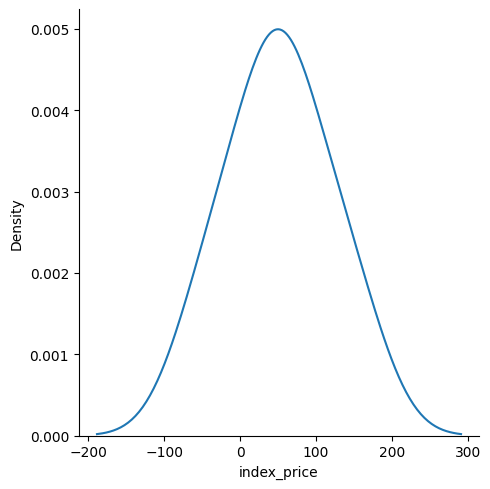

In [84]:
##With PCA
##Plotting residuals to check Normality 

sns.displot(y_test -y_pred,kind = 'kde')

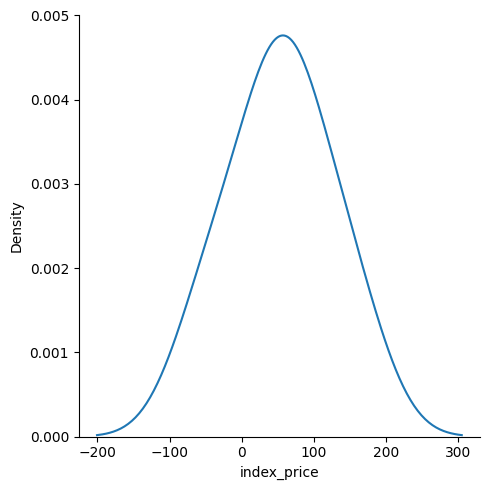

In [85]:
##Without PCA
##Plotting residuals to check Normality 

sns.displot(y_test -y_pred1,kind = 'kde')

<h4> How good is the estimation </h4>

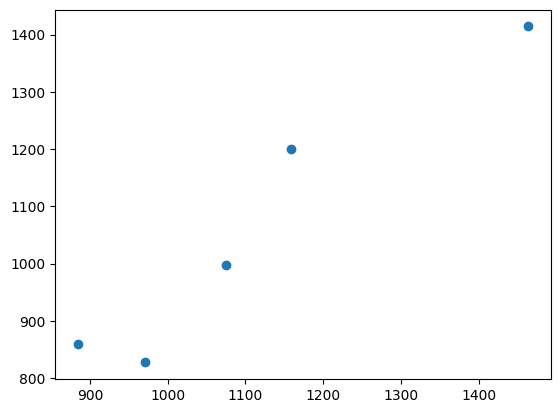

In [ ]:
# With PCA
plt.scatter(y_test,y_pred) ## It is diagonal more or less

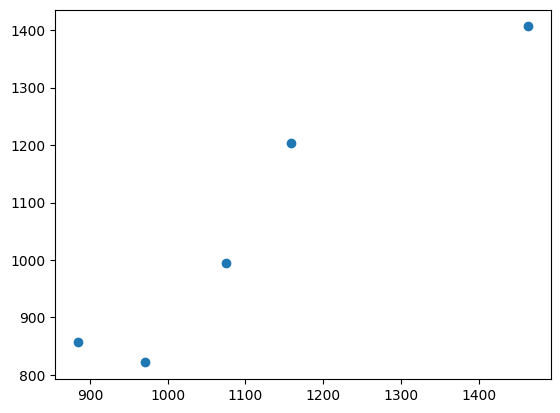

In [ ]:
##Without PCA
plt.scatter(y_test,y_pred1) ## It is diagonal more or less

<h4> Homoscedastic </h4>

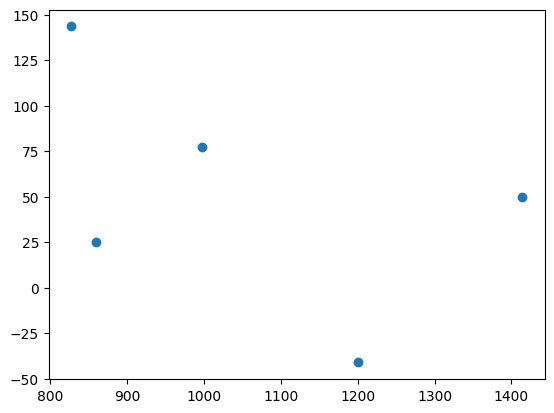

In [89]:
##with Pca
plt.scatter(y_pred,y_test -y_pred)

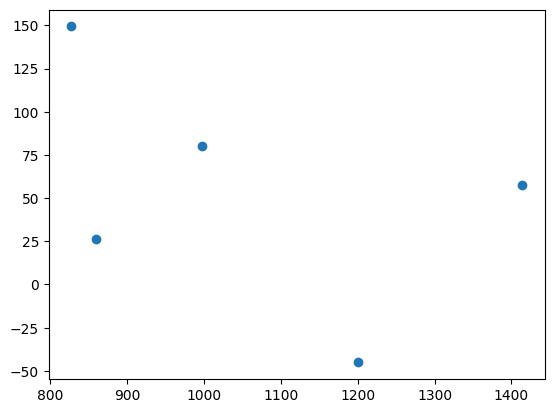

In [90]:
#Without PCA
plt.scatter(y_pred,y_test -y_pred1)

In [91]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train_scal).fit()

In [95]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Wed, 01 Oct 2025   Prob (F-statistic):                       0.751
Time:                        11:11:11   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [94]:
print(lr.coef_)

[  86.63351334 -114.04857249]
